# Generalized Roughness Analysis Notebook

This notebook reproduces the core plots from roughness.ipynb for all station files:
- Cell 12 figure: three histograms by wind-direction regime
- Cell 17 figure: box plot of z0 at 1m
- Cell 18 figure: box plots of z0 for all available heights
- Cell 21 figure: FFC map for each wind-direction regime

All station-specific constants are configured in one place (next cell).

In [1]:
import re
from pathlib import Path
from typing import Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import src.calc_footprint_FFP_climatology as footprint
from src.flux_footprints import subset_or_resample, filter_ffp

plt.rcParams['figure.dpi'] = 120

## Station Configuration

Fill in or adjust station metadata here:
- sensor_heights_m: exact sensor heights above displacement height for each level
- coordinates_lv95: station map origin for FFC plotting
- wind_regimes: station-specific direction regimes

Filter settings are set to match the current roughness.ipynb defaults.

In [2]:
# ------------------------------------------------------------------------------
# Global preprocessing settings (same defaults as roughness.ipynb)
# ------------------------------------------------------------------------------
GLOBAL_TIME_WINDOW = None
GLOBAL_RESAMPLE_MINUTES = None
STABILITY_RANGE = (-0.1, 0.2)

PREPROCESS = {
    'wind_dir_range': None,
    'wind_speed_range': (1, 50),
    'uw_jet_filter': True,
    'uT_jet_filter': False,
    'jet_dir_range_name': 'katabatic',
    'ustar_range': None,
    'ustar_min': 0.1,
}

# ------------------------------------------------------------------------------
# FFC settings (same defaults as roughness.ipynb Cell 21)
# ------------------------------------------------------------------------------
FFC_SETTINGS = {
    'height': '1m',
    'resample_minutes': None,
    'time_window': None,
    'uw_jet_filter': False,
    'uT_jet_filter': False,
    'wind_speed_range': None,
    'jet_filter_regime_name': 'katabatic',
    'domain': [-100, 100, -100, 100],
    'dx': 0.5,
    'dy': 0.5,
    'pbl_height_m': 100.0,
    'map_overlay': True,
    'contour_line_width': 1,
    'contour_line_color': 'darkgreen',
}

# ------------------------------------------------------------------------------
# Station list: edit values here
# Wind-direction regimes are defined per station (not global).
# ------------------------------------------------------------------------------
STATIONS = {
    'SILVEX1_Silvia1': {
        'file_path': 'Data/SILVEX1_Silvia1_roughness_ffp_data.CSV',
        'sensor_heights_m': {'1m': 1.05, '2m': 2.3},
        'coordinates_lv95': (2800043, 1192728),
        'wind_regimes': {
            'katabatic': (80, 130),
            'crosswind': (170, 230),
            'anabatic': (240, 300),
        },
    },
    'SILVEX1_Silvia2': {
        'file_path': 'Data/SILVEX1_Silvia2_roughness_ffp_data.CSV',
        'sensor_heights_m': {'1m': 1.1, '2m': 2.4},
        'coordinates_lv95': (2801132, 1192502),
        'wind_regimes': {
            'katabatic': (100, 160),
            'crosswind': (170, 230),
            'anabatic': (240, 300),
        },
    },
    'SILVEX1_Silvia3': {
        'file_path': 'Data/SILVEX1_Silvia3_roughness_ffp_data.CSV',
        'sensor_heights_m': {'1m': 1.15, '2m': 2.45},
        'coordinates_lv95': (2800419, 1192781),
        'wind_regimes': {
            'katabatic': (80, 130),
            'crosswind': (170, 230),
            'anabatic': (240, 300),
        },
    },
    'SILVEX2_Silvia1': {
        'file_path': 'Data/SILVEX2_Silvia1_roughness_ffp_data.CSV',
        'sensor_heights_m': {'1m': 1.15, '2m': 2.05, '3m': 3.05},
        'coordinates_lv95': (2800713, 1192663),
        'wind_regimes': {
            'katabatic': (90, 150),
            'crosswind': (170, 230),
            'anabatic': (240, 300),
        },
    },
    'SILVEX2_Silvia2': {
        'file_path': 'Data/SILVEX2_Silvia2_roughness_ffp_data.CSV',
        'sensor_heights_m': {'1m': 1.1, '2m': 2.1, '3m': 3.1},
        'coordinates_lv95': (2800833, 1192609),
        'wind_regimes': {
            'katabatic': (90, 150),
            'crosswind': (170, 230),
            'anabatic': (240, 300),
        },
    },
}

# Output folders
FIG_ROOT = Path('Figures/roughness_generalized')
FIG_ROOT.mkdir(parents=True, exist_ok=True)

# Histogram cap from original notebook
HIST_Z0_MAX_M = 0.025

In [3]:
def direction_mask(series: pd.Series, rng: Optional[Tuple[float, float]]) -> pd.Series:
    if rng is None:
        return pd.Series(True, index=series.index)
    lo, hi = rng
    vals = pd.to_numeric(series, errors='coerce') % 360
    if lo <= hi:
        return vals.between(lo, hi, inclusive='both')
    return (vals >= lo) | (vals <= hi)


def detect_levels(columns) -> list:
    levels = []
    for col in columns:
        m = re.fullmatch(r'wind_dir_(\dm)', col)
        if m:
            levels.append(m.group(1))
    return sorted(levels, key=lambda x: int(x.replace('m', '')))


def preprocess_station(file_path: str, station_cfg: dict):
    df = pd.read_csv(file_path, sep=';', low_memory=False)

    # Remove unit row and build datetime index
    df_clean = df.iloc[1:].copy()
    df_clean['datetime'] = pd.to_datetime(
        df_clean['date'].astype(str) + ' ' + df_clean['time'].astype(str),
        format='%d.%m.%Y %H:%M',
        errors='coerce',
    )
    df_clean = df_clean.dropna(subset=['datetime'])
    df_clean = df_clean.set_index('datetime').sort_index()

    # Detect levels available in this station file
    levels = detect_levels(df_clean.columns)
    if not levels:
        raise ValueError(f'No wind_dir_<level> columns found in {file_path}')

    # Convert all non-date/time columns to numeric where possible
    for col in df_clean.columns:
        if col not in {'date', 'time'}:
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

    # Build per-level column groups for level-wise masking
    level_cols = {lvl: [c for c in df_clean.columns if c.endswith(f'_{lvl}') or c == f'z0_{lvl}'] for lvl in levels}

    # Apply global subset/resample
    df_clean = subset_or_resample(
        df_clean,
        resample_minutes=GLOBAL_RESAMPLE_MINUTES,
        time_window=GLOBAL_TIME_WINDOW,
    )

    # Stability filter
    for lvl in levels:
        col = f'(z-d)/L_{lvl}'
        if col in df_clean.columns:
            lo, hi = STABILITY_RANGE
            df_clean.loc[(df_clean[col] < lo) | (df_clean[col] > hi), col] = np.nan

    # Regime used for jet-direction filter during preprocessing
    regimes = station_cfg['wind_regimes']
    jet_dir_range = regimes.get(PREPROCESS['jet_dir_range_name'])

    # Apply level-wise masks exactly as in roughness.ipynb
    for lvl in levels:
        lvl_mask = pd.Series(True, index=df_clean.index)

        wd_col = f'wind_dir_{lvl}'
        ws_col = f'wind_speed_{lvl}'
        us_col = f'u*_{lvl}'
        uw_col = f'cov_uw_{lvl}'
        uT_col = f'cov_uT_{lvl}'

        lvl_mask &= direction_mask(df_clean.get(wd_col, pd.Series(index=df_clean.index)), PREPROCESS['wind_dir_range'])

        if PREPROCESS['wind_speed_range'] is not None and ws_col in df_clean.columns:
            ws_lo, ws_hi = PREPROCESS['wind_speed_range']
            ws = pd.to_numeric(df_clean[ws_col], errors='coerce')
            lvl_mask &= ws.between(ws_lo, ws_hi, inclusive='both')

        if PREPROCESS['ustar_range'] is not None and us_col in df_clean.columns:
            us_lo, us_hi = PREPROCESS['ustar_range']
            us = pd.to_numeric(df_clean[us_col], errors='coerce')
            lvl_mask &= us.between(us_lo, us_hi, inclusive='both')

        if PREPROCESS['ustar_min'] is not None and us_col in df_clean.columns:
            us = pd.to_numeric(df_clean[us_col], errors='coerce')
            lvl_mask &= us >= PREPROCESS['ustar_min']

        jet_mask = direction_mask(df_clean.get(wd_col, pd.Series(index=df_clean.index)), jet_dir_range)

        if PREPROCESS['uw_jet_filter'] and uw_col in df_clean.columns:
            lvl_mask &= (~jet_mask) | (df_clean[uw_col] <= 0)

        if PREPROCESS['uT_jet_filter'] and uT_col in df_clean.columns:
            lvl_mask &= (~jet_mask) | (df_clean[uT_col] >= 0)

        if level_cols[lvl]:
            df_clean.loc[~lvl_mask, level_cols[lvl]] = np.nan

    return df_clean, levels


def plot_cell12_histograms(df_plot: pd.DataFrame, regimes: dict, station_name: str, outdir: Path):
    req = ['wind_speed_1m', 'u*_1m', 'wind_dir_1m', '(z-d)/L_1m']
    if not all(c in df_plot.columns for c in req):
        print(f'[{station_name}] Skipping Cell 12 figure (missing 1m columns).')
        return

    ws_1m = pd.to_numeric(df_plot['wind_speed_1m'], errors='coerce')
    us_1m = pd.to_numeric(df_plot['u*_1m'], errors='coerce')
    wd_1m = pd.to_numeric(df_plot['wind_dir_1m'], errors='coerce')
    zdl_1m = pd.to_numeric(df_plot['(z-d)/L_1m'], errors='coerce')

    mk = direction_mask(wd_1m, regimes['katabatic'])
    mc = direction_mask(wd_1m, regimes['crosswind'])
    ma = direction_mask(wd_1m, regimes['anabatic'])

    fig, (ax_a, ax_b, ax_c) = plt.subplots(1, 3, figsize=(18, 5))

    ax_a.hist(zdl_1m[mk].dropna(), bins=50, label='katabatic', density=True, color='steelblue', alpha=0.5)
    ax_a.hist(zdl_1m[mc].dropna(), bins=50, label='crosswind', density=True, color='seagreen', alpha=0.5)
    ax_a.hist(zdl_1m[ma].dropna(), bins=50, label='anabatic', density=True, color='darkorange', alpha=0.5)
    ax_a.set_xlabel('(z-d)/L (1 m) [-]')
    ax_a.set_ylabel('Probability Density')
    ax_a.set_title(f'{station_name}: (z-d)/L by Regime (1 m)')
    ax_a.grid(True, alpha=0.3)
    ax_a.axvline(x=0, color='k', linestyle='--', linewidth=0.8)
    ax_a.set_xlim(-0.2, 0.3)
    ax_a.legend()

    ax_b.hist(ws_1m[mk].dropna(), bins=50, label='katabatic', density=True, color='steelblue', alpha=0.5)
    ax_b.hist(ws_1m[mc].dropna(), bins=50, label='crosswind', density=True, color='seagreen', alpha=0.5)
    ax_b.hist(ws_1m[ma].dropna(), bins=50, label='anabatic', density=True, color='darkorange', alpha=0.5)
    ax_b.set_xlabel('Wind Speed (1 m) [m/s]')
    ax_b.set_ylabel('Probability Density')
    ax_b.set_title(f'{station_name}: Wind Speed by Regime (1 m)')
    ax_b.grid(True, alpha=0.3)
    ax_b.legend()

    ax_c.hist(us_1m[mk].dropna(), bins=80, label='katabatic', density=True, color='steelblue', alpha=0.5)
    ax_c.hist(us_1m[mc].dropna(), bins=80, label='crosswind', density=True, color='seagreen', alpha=0.5)
    ax_c.hist(us_1m[ma].dropna(), bins=80, label='anabatic', density=True, color='darkorange', alpha=0.5)
    ax_c.set_xlabel('Friction Velocity u* (1 m) [m/s]')
    ax_c.set_ylabel('Probability Density')
    ax_c.set_title(f'{station_name}: u* by Regime (1 m)')
    ax_c.grid(True, alpha=0.3)
    ax_c.set_xlim(0, 2)
    ax_c.legend()

    plt.tight_layout()
    fig.savefig(outdir / f'{station_name}_cell12_histograms.png', bbox_inches='tight')
    plt.show()


def plot_cell17_box_1m(df_plot: pd.DataFrame, regimes: dict, station_name: str, outdir: Path):
    req = ['wind_dir_1m', 'z0_1m']
    if not all(c in df_plot.columns for c in req):
        print(f'[{station_name}] Skipping Cell 17 figure (missing 1m columns).')
        return

    wd_1m = pd.to_numeric(df_plot['wind_dir_1m'], errors='coerce') % 360
    z0_1m_mm = pd.to_numeric(df_plot['z0_1m'], errors='coerce') * 1000

    mk = direction_mask(wd_1m, regimes['katabatic'])
    mc = direction_mask(wd_1m, regimes['crosswind'])
    ma = direction_mask(wd_1m, regimes['anabatic'])

    data_mm = [z0_1m_mm[mk].dropna(), z0_1m_mm[mc].dropna(), z0_1m_mm[ma].dropna()]
    labels = [
        f'katabatic (n={len(data_mm[0])})',
        f'crosswind (n={len(data_mm[1])})',
        f'anabatic (n={len(data_mm[2])})',
    ]
    colors = ['steelblue', 'seagreen', 'darkorange']

    fig, ax = plt.subplots(figsize=(7, 6))
    bp0 = ax.boxplot(
        data_mm,
        tick_labels=labels,
        vert=True,
        patch_artist=True,
        showfliers=True,
        medianprops={'color': 'black', 'linewidth': 1.2},
    )
    for patch, color in zip(bp0['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    ax.set_title(f'{station_name}: z0 (1 m) by Wind Direction Regime')
    ax.set_ylabel('z0 [mm]')
    ax.grid(True, axis='y', alpha=0.3)

    all_data = pd.concat(data_mm) if len(data_mm) else pd.Series(dtype=float)
    upper_lim_mm = all_data.quantile(0.99) if not all_data.empty else None
    if pd.notna(upper_lim_mm):
        ax.set_ylim(-10, upper_lim_mm * 1.2)

    plt.tight_layout()
    fig.savefig(outdir / f'{station_name}_cell17_box_1m.png', bbox_inches='tight')
    plt.show()


def plot_cell18_box_all_heights(df_plot: pd.DataFrame, levels: list, regimes: dict, station_name: str, outdir: Path):
    levels = [lvl for lvl in levels if f'z0_{lvl}' in df_plot.columns and f'wind_dir_{lvl}' in df_plot.columns]
    if not levels:
        print(f'[{station_name}] Skipping Cell 18 figure (no matching z0/wind_dir levels).')
        return

    sectors = [('katabatic', regimes['katabatic']), ('crosswind', regimes['crosswind']), ('anabatic', regimes['anabatic'])]
    sector_colors = ['steelblue', 'seagreen', 'darkorange']

    fig, axes = plt.subplots(1, len(levels), figsize=(5 * len(levels), 6), sharey=True)
    if len(levels) == 1:
        axes = [axes]

    all_data = []

    for ax, lvl in zip(axes, levels):
        wd = pd.to_numeric(df_plot[f'wind_dir_{lvl}'], errors='coerce')
        z0_mm = pd.to_numeric(df_plot[f'z0_{lvl}'], errors='coerce') * 1000

        labels = []
        data_mm = []
        for (name, rng), color in zip(sectors, sector_colors):
            mask = direction_mask(wd, rng)
            subset = z0_mm[mask].dropna()
            data_mm.append(subset)
            labels.append(f'{name} (n={len(subset)})')

        bp = ax.boxplot(
            data_mm,
            tick_labels=labels,
            vert=True,
            patch_artist=True,
            showfliers=True,
            medianprops={'color': 'black', 'linewidth': 1.2},
        )
        for patch, color in zip(bp['boxes'], sector_colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.6)

        ax.set_title(f'{station_name}: z0 ({lvl})')
        ax.set_xlabel('Wind direction sectors')
        ax.grid(True, axis='y', alpha=0.3)

        all_data.extend(data_mm)

    axes[0].set_ylabel('z0 [mm]')

    if all_data:
        upper_lim_mm = pd.concat(all_data).quantile(0.99)
        if pd.notna(upper_lim_mm):
            axes[0].set_ylim(-10, upper_lim_mm * 1.2)

    plt.tight_layout()
    fig.savefig(outdir / f'{station_name}_cell18_box_all_heights.png', bbox_inches='tight')
    plt.show()


def plot_cell21_ffc_per_regime(df_clean: pd.DataFrame, station_name: str, station_cfg: dict, outdir: Path):
    height = FFC_SETTINGS['height']
    needed_cols = [f'wind_speed_{height}', f'L_{height}', f'u*_{height}', f'var_v_{height}', f'wind_dir_{height}']
    if not all(c in df_clean.columns for c in needed_cols):
        print(f'[{station_name}] Skipping Cell 21 figure (missing columns for {height}).')
        return []

    x0, y0 = station_cfg['coordinates_lv95']
    if FFC_SETTINGS['map_overlay'] and (x0 is None or y0 is None):
        print(f'[{station_name}] Skipping Cell 21 figure (coordinates_lv95 not set).')
        return []

    if height not in station_cfg['sensor_heights_m']:
        print(f'[{station_name}] Skipping Cell 21 figure (sensor_heights_m missing for {height}).')
        return []

    df_ffp = subset_or_resample(
        df_clean.copy(),
        resample_minutes=FFC_SETTINGS['resample_minutes'],
        time_window=FFC_SETTINGS['time_window'],
    )

    if df_ffp.empty:
        print(f'[{station_name}] Skipping Cell 21 figure (empty after FFC resample/time window).')
        return []

    results = []
    regimes = station_cfg['wind_regimes']
    jet_rng = regimes.get(FFC_SETTINGS['jet_filter_regime_name'])

    for regime_name, regime_rng in regimes.items():
        filtered = filter_ffp(
            df_ffp,
            height=height,
            wind_dir_range=regime_rng,
            jet_filter_range=jet_rng,
            uw_jet_filter=FFC_SETTINGS['uw_jet_filter'],
            uT_jet_filter=FFC_SETTINGS['uT_jet_filter'],
            wind_speed_range=FFC_SETTINGS['wind_speed_range'],
        )

        filtered = filtered.dropna(subset=needed_cols).copy()
        filtered['sigmav'] = np.sqrt(filtered[f'var_v_{height}'])
        filtered = filtered.dropna(subset=['sigmav'])

        if filtered.empty:
            print(f'[{station_name}] Regime {regime_name}: no samples after filtering.')
            continue

        kwargs = dict(
            zm=station_cfg['sensor_heights_m'][height],
            z0=None,
            umean=filtered[f'wind_speed_{height}'].tolist(),
            h=[FFC_SETTINGS['pbl_height_m']] * len(filtered),
            ol=filtered[f'L_{height}'].tolist(),
            sigmav=filtered['sigmav'].tolist(),
            ustar=filtered[f'u*_{height}'].tolist(),
            wind_dir=filtered[f'wind_dir_{height}'].tolist(),
            verbosity=0,
            fig=True,
            show_heatmap=False,
            domain=FFC_SETTINGS['domain'],
            dx=FFC_SETTINGS['dx'],
            dy=FFC_SETTINGS['dy'],
            map_overlay=FFC_SETTINGS['map_overlay'],
            map_origin=(x0, y0),
            map_origin_crs='LV95',
            map_origin_label=station_name,
            contour_line_width=FFC_SETTINGS['contour_line_width'],
            contour_line_color=FFC_SETTINGS['contour_line_color'],
        )

        # Fallback if map overlay dependencies are not available
        try:
            FFP = footprint.FFP_climatology(**kwargs)
        except Exception as exc:
            print(f'[{station_name}] Regime {regime_name}: map overlay failed ({exc}); retrying without map overlay.')
            kwargs['map_overlay'] = False
            FFP = footprint.FFP_climatology(**kwargs)

        fig = plt.gcf()
        fig.savefig(outdir / f'{station_name}_cell21_ffc_{regime_name}.png', bbox_inches='tight')
        plt.show()

        results.append({'station': station_name, 'regime': regime_name, 'n_samples': len(filtered)})

    return results


Processing SILVEX1_Silvia1
[SILVEX1_Silvia1] Rows after preprocessing: 22867
[SILVEX1_Silvia1] Levels detected: ['1m', '2m']


h:\Code\ec-processing\.venv\Lib\site-packages\numpy\lib\_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


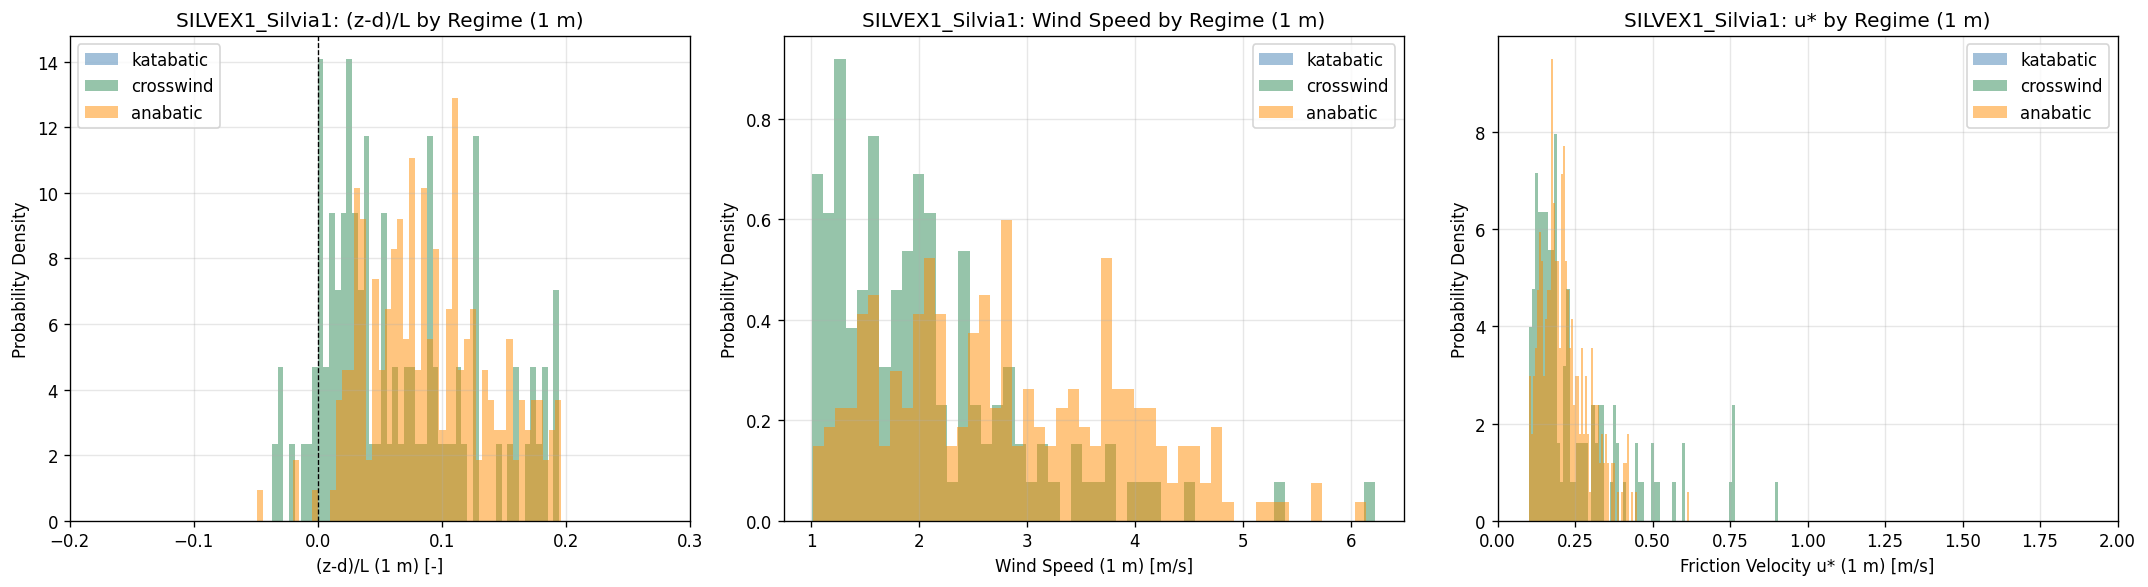

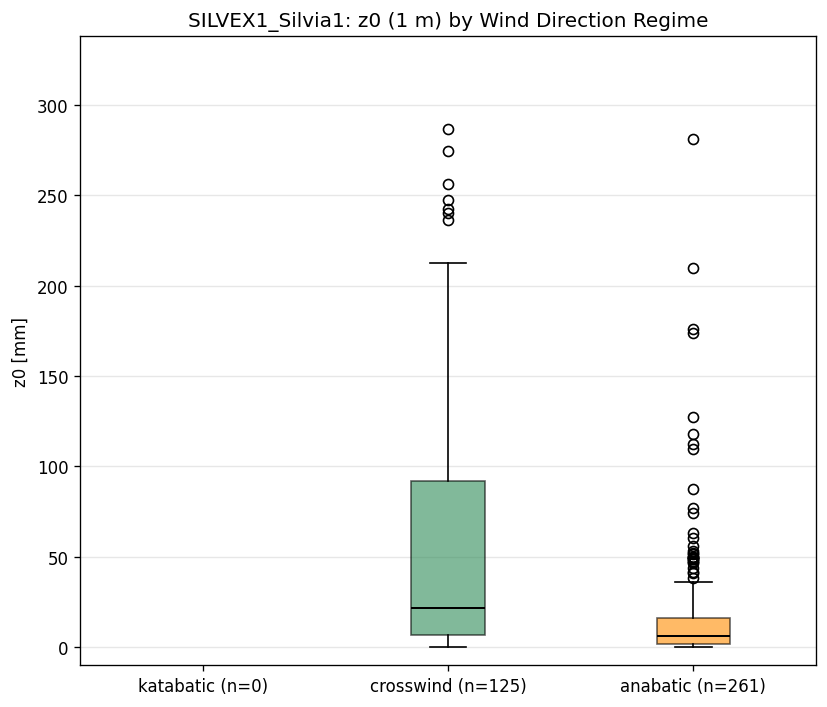

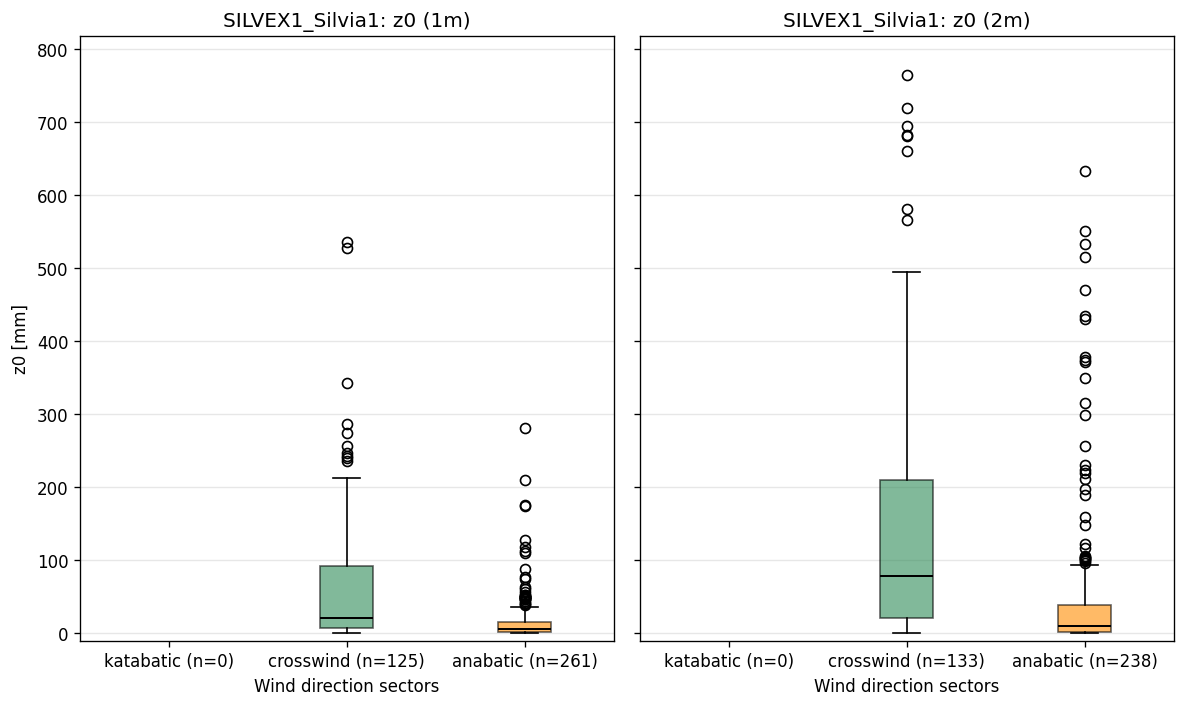

Data successfully filtered!
[SILVEX1_Silvia1] Regime katabatic: no samples after filtering.
Data successfully filtered!


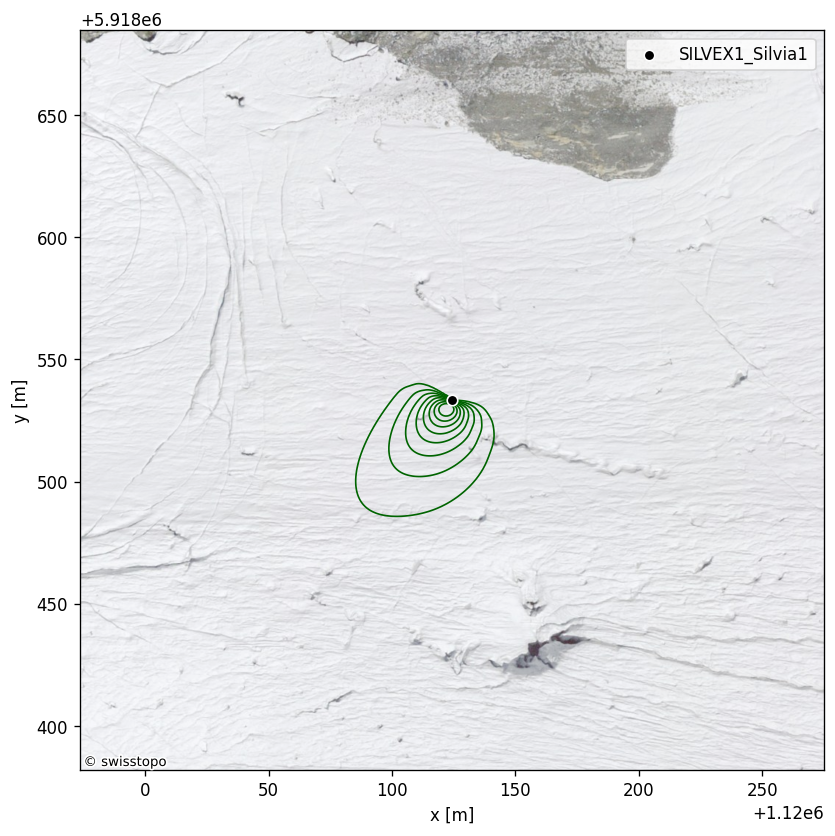

<Figure size 768x576 with 0 Axes>

Data successfully filtered!


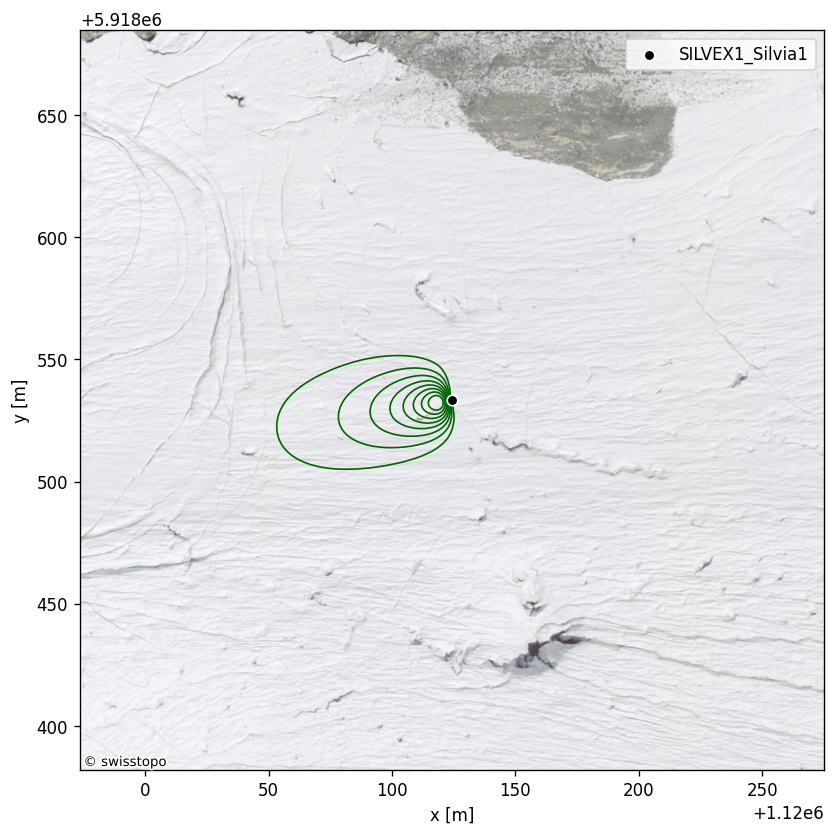

<Figure size 768x576 with 0 Axes>


Processing SILVEX1_Silvia2
[SILVEX1_Silvia2] Rows after preprocessing: 24337
[SILVEX1_Silvia2] Levels detected: ['1m', '2m']


h:\Code\ec-processing\.venv\Lib\site-packages\numpy\lib\_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


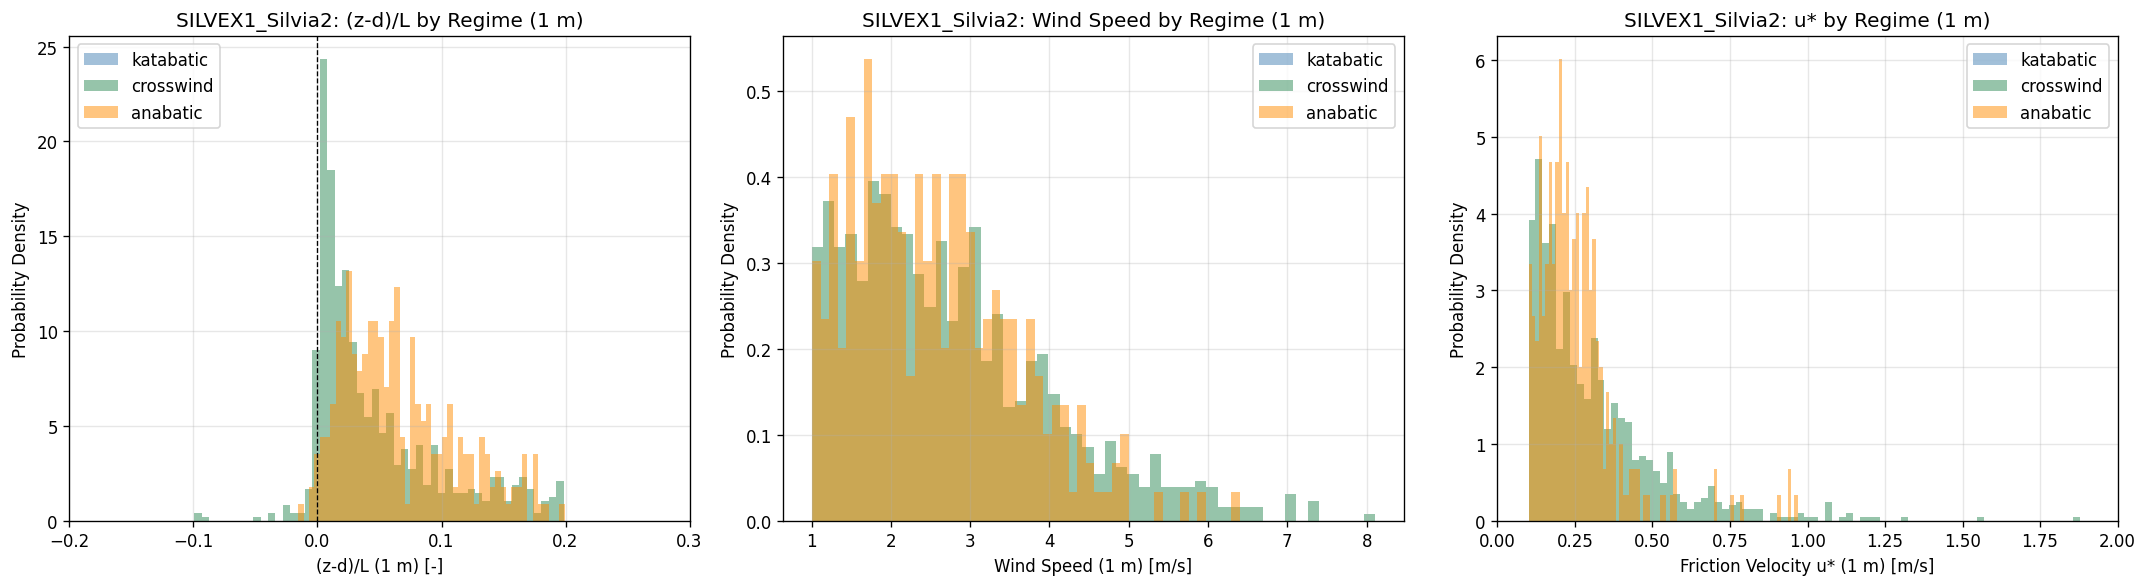

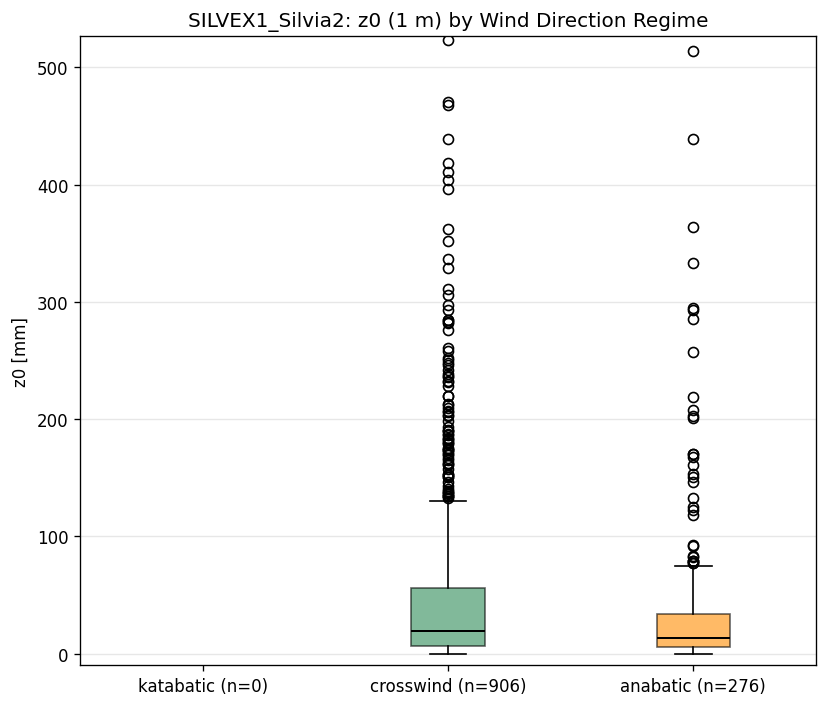

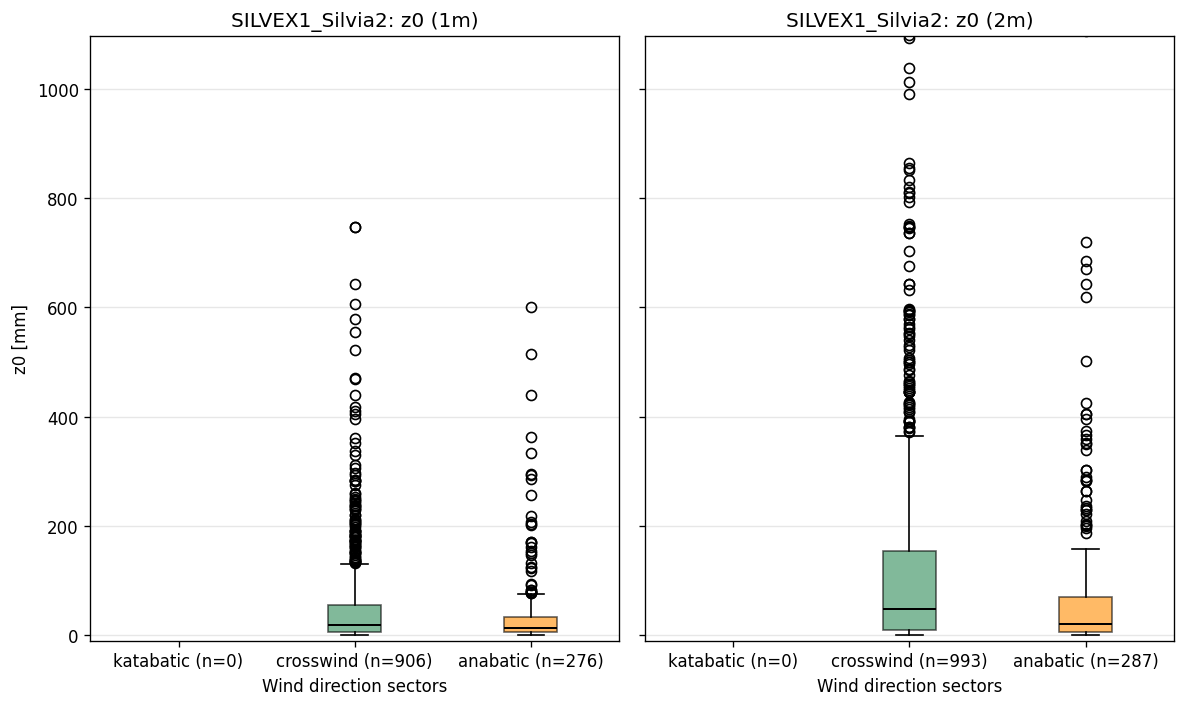

Data successfully filtered!
[SILVEX1_Silvia2] Regime katabatic: no samples after filtering.
Data successfully filtered!


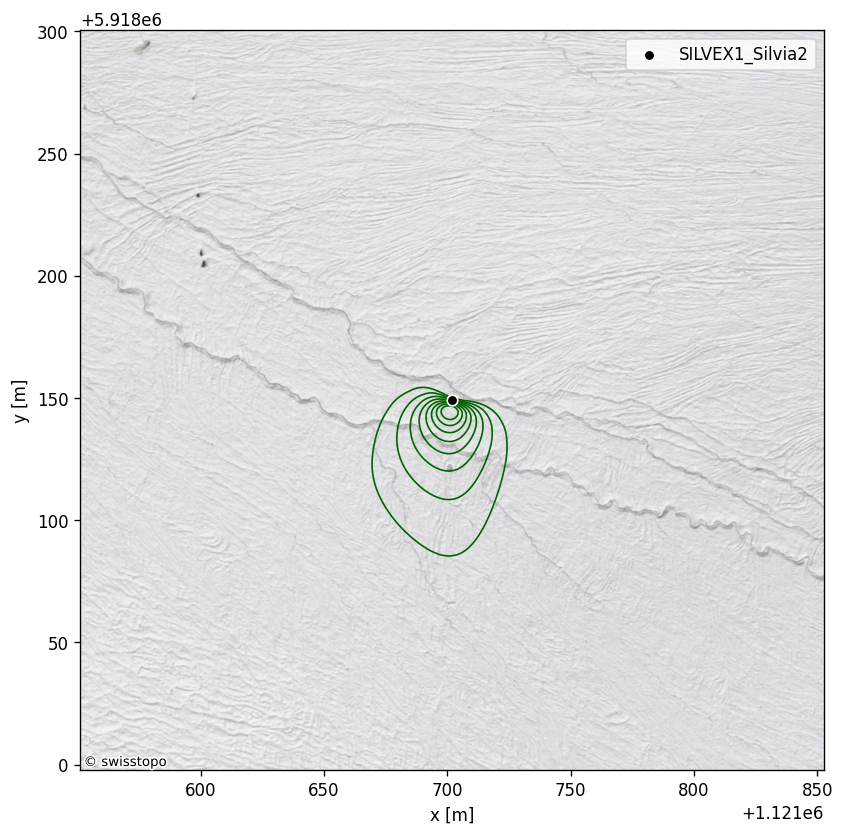

<Figure size 768x576 with 0 Axes>

Data successfully filtered!


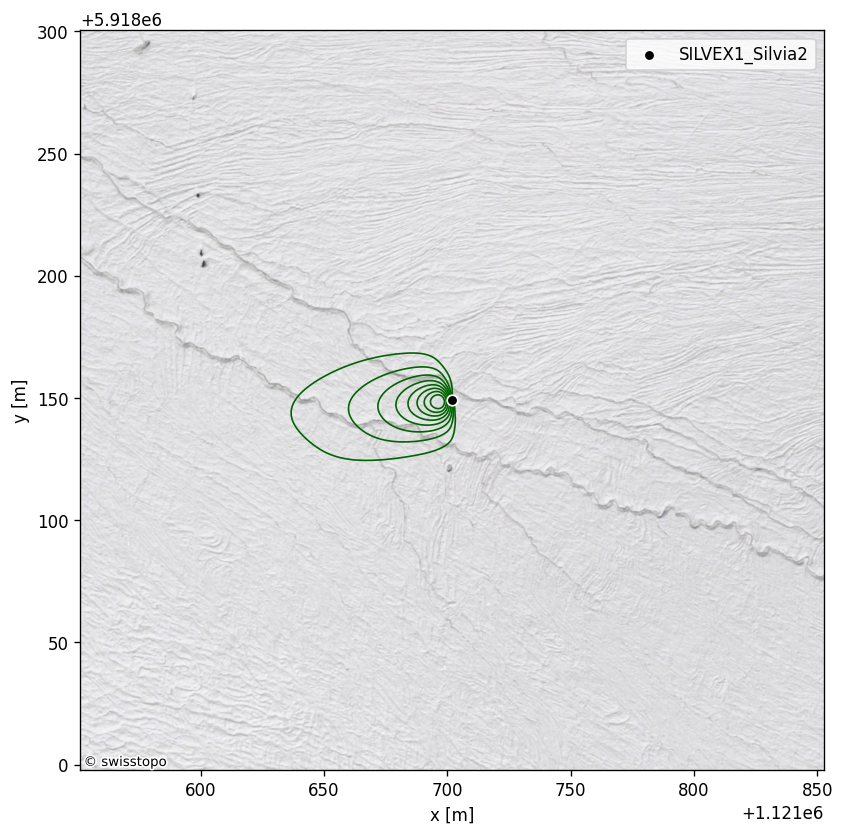

<Figure size 768x576 with 0 Axes>


Processing SILVEX1_Silvia3
[SILVEX1_Silvia3] Rows after preprocessing: 24504
[SILVEX1_Silvia3] Levels detected: ['1m', '2m']


h:\Code\ec-processing\.venv\Lib\site-packages\numpy\lib\_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


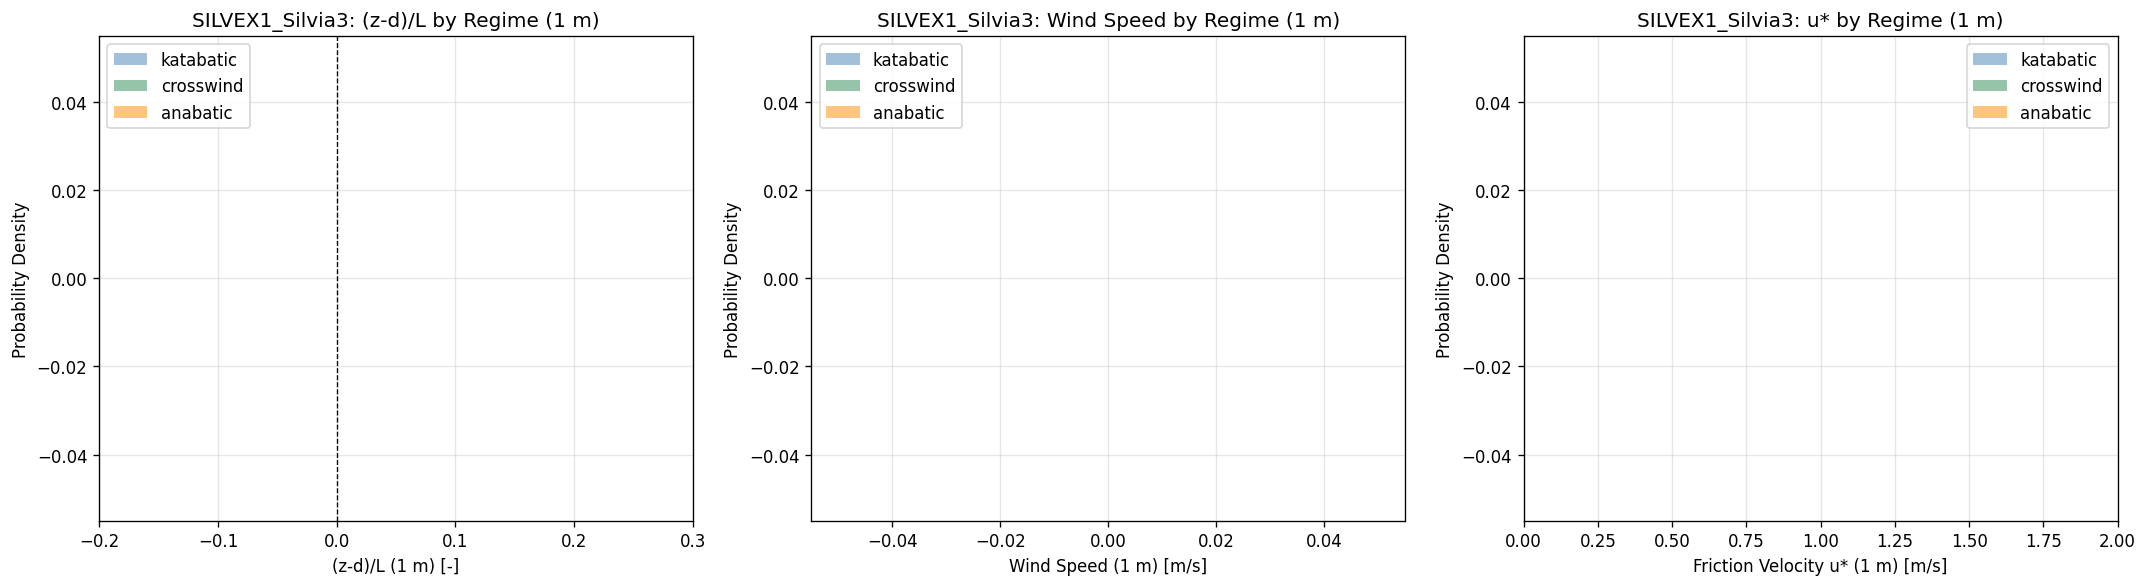

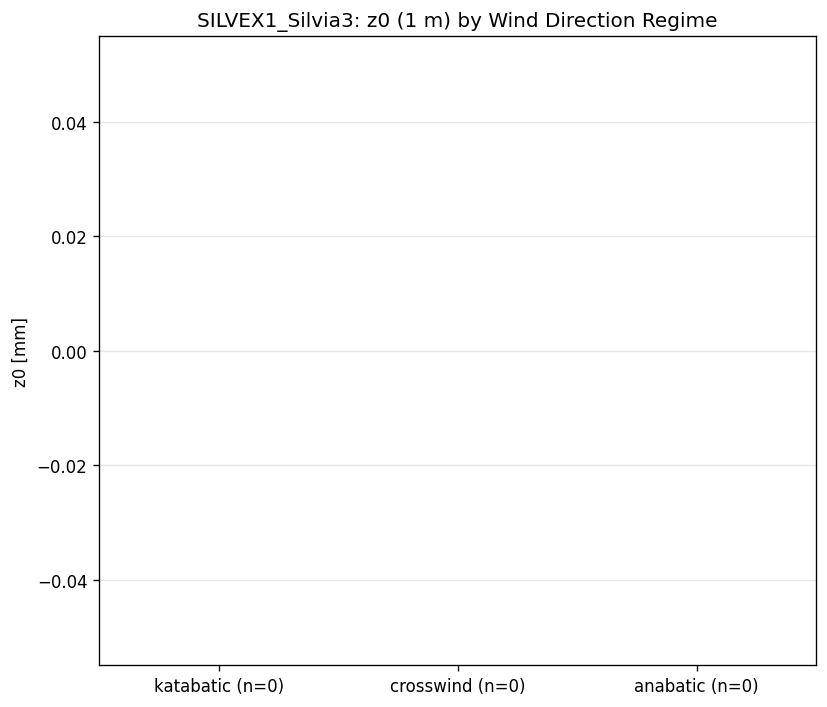

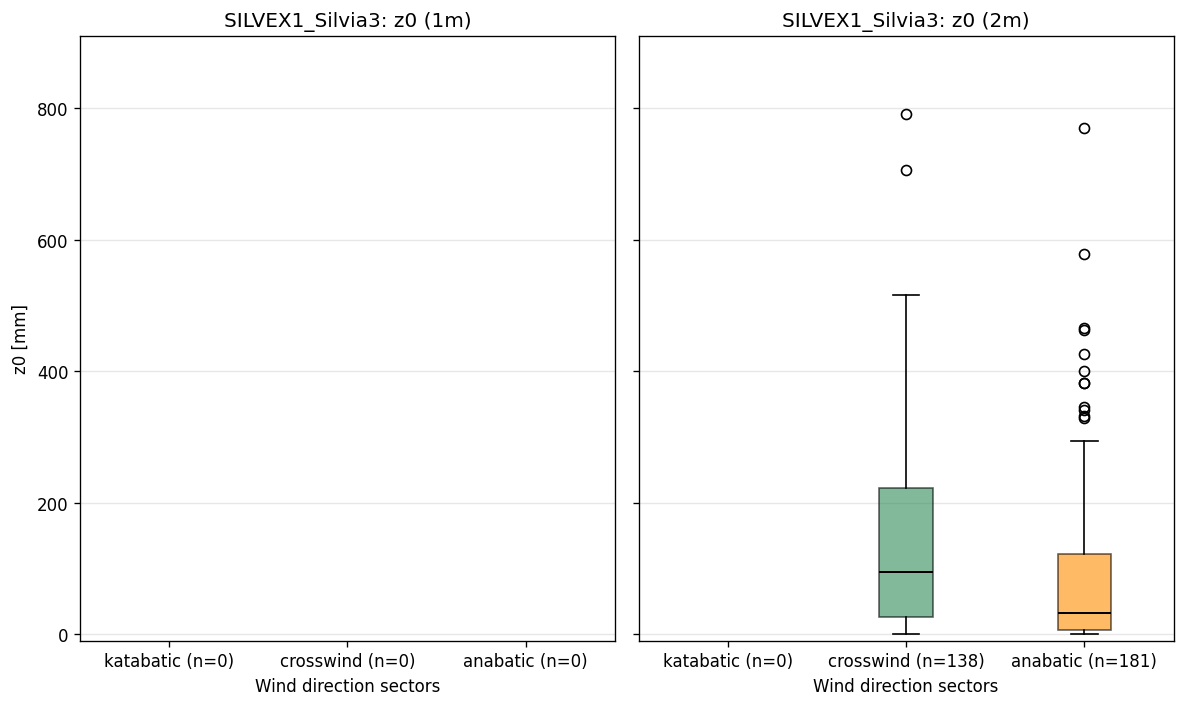

Data successfully filtered!
[SILVEX1_Silvia3] Regime katabatic: no samples after filtering.
Data successfully filtered!
[SILVEX1_Silvia3] Regime crosswind: no samples after filtering.
Data successfully filtered!
[SILVEX1_Silvia3] Regime anabatic: no samples after filtering.

Processing SILVEX2_Silvia1
[SILVEX2_Silvia1] Rows after preprocessing: 43281
[SILVEX2_Silvia1] Levels detected: ['1m', '2m', '3m']


h:\Code\ec-processing\.venv\Lib\site-packages\numpy\lib\_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


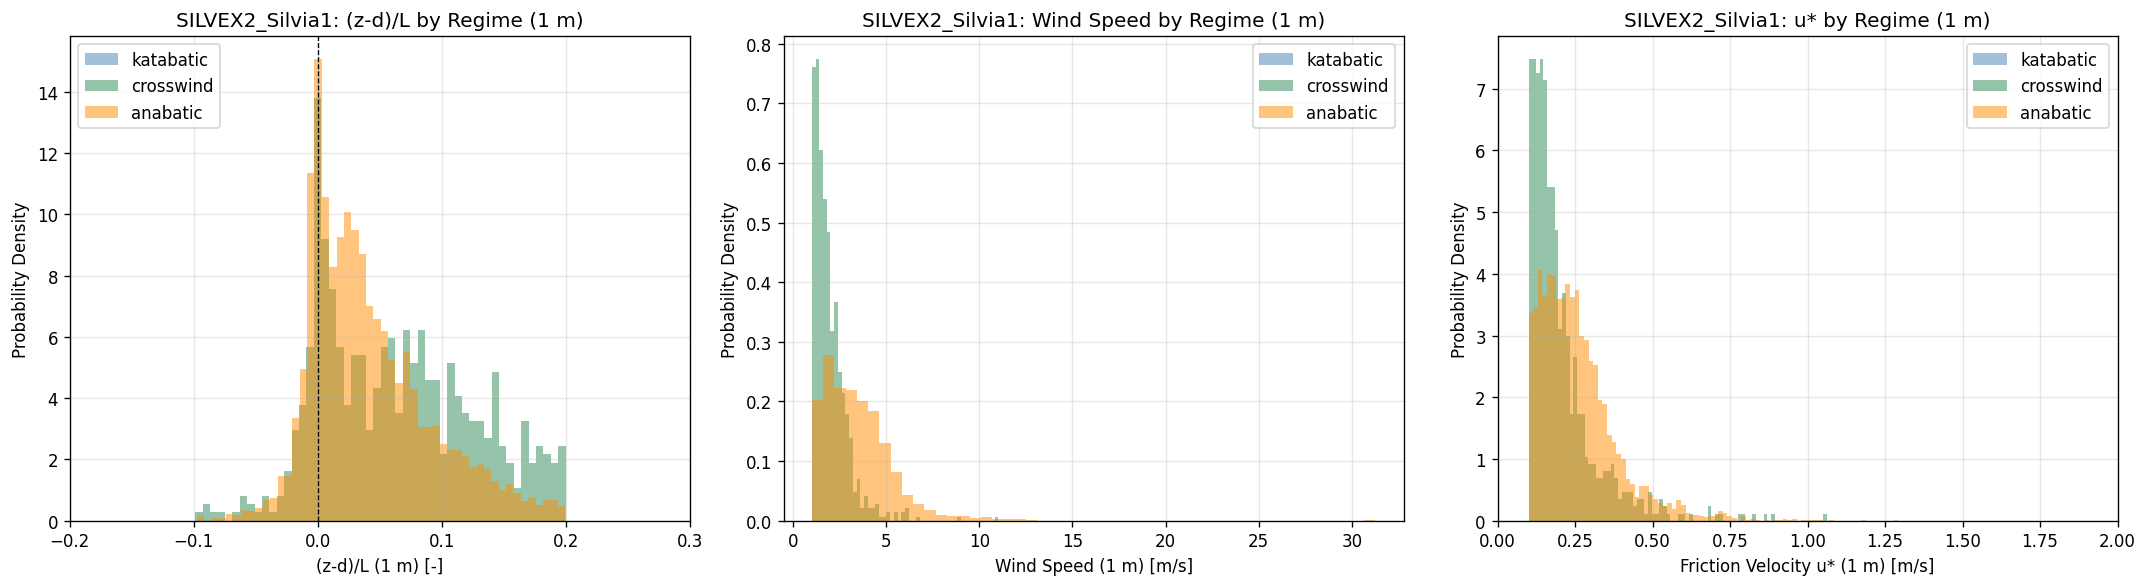

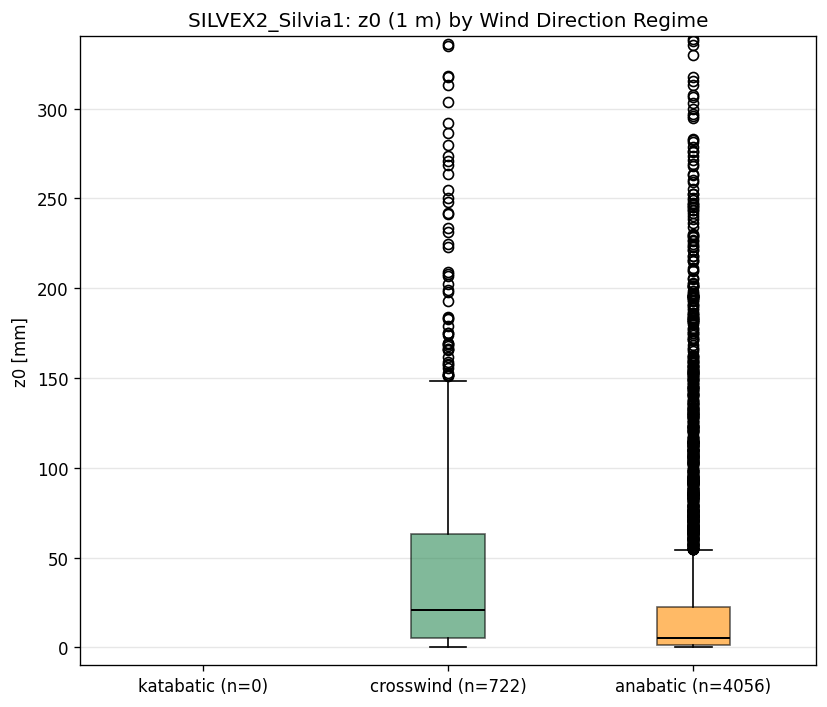

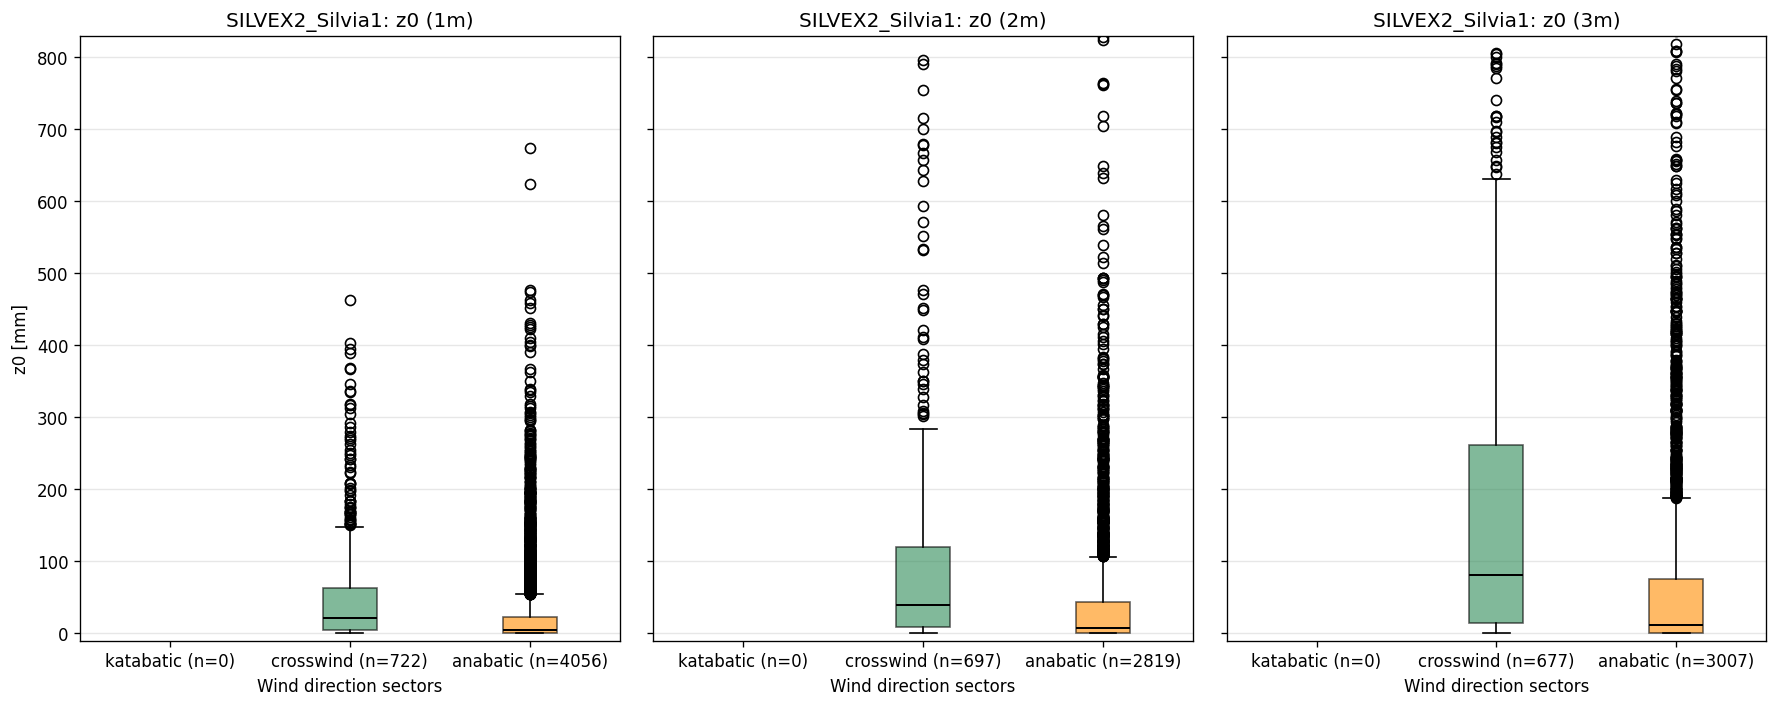

Data successfully filtered!
[SILVEX2_Silvia1] Regime katabatic: no samples after filtering.
Data successfully filtered!


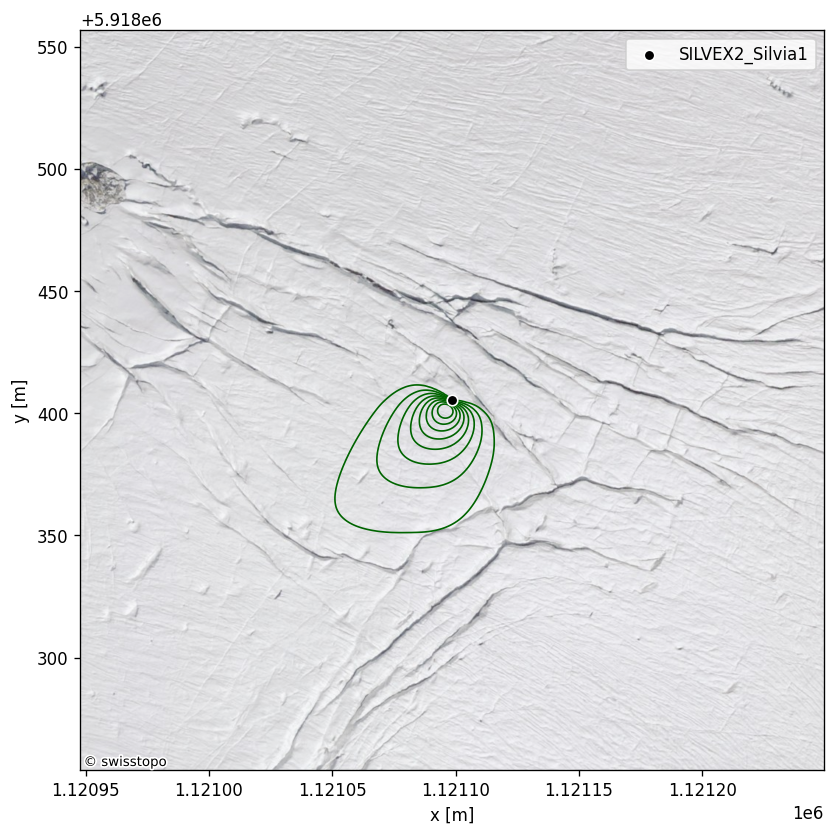

<Figure size 768x576 with 0 Axes>

Data successfully filtered!


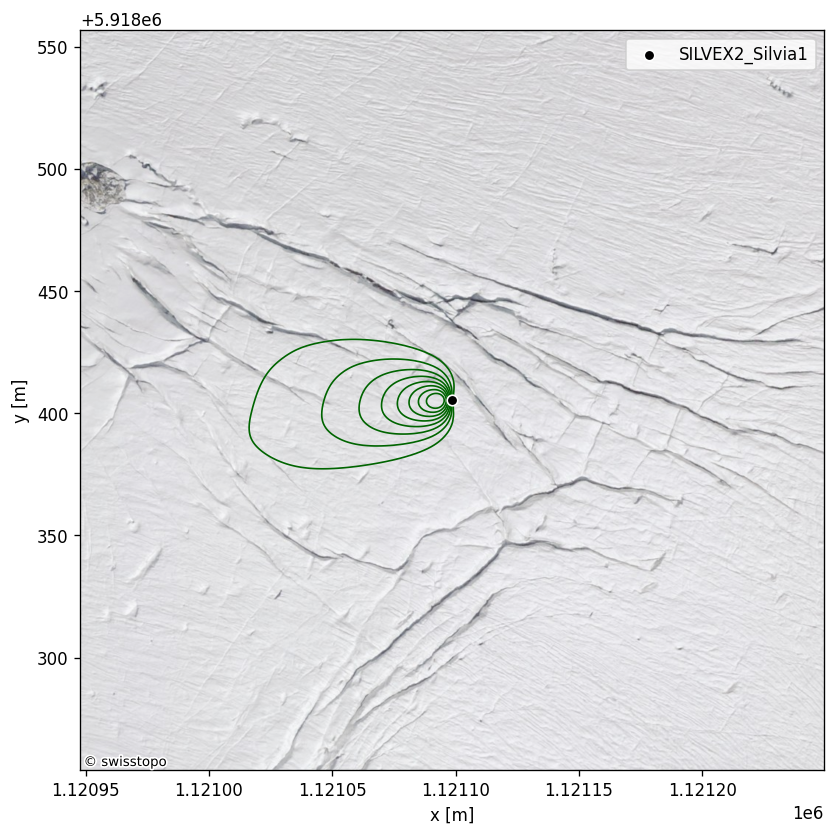

<Figure size 768x576 with 0 Axes>


Processing SILVEX2_Silvia2
[SILVEX2_Silvia2] Rows after preprocessing: 43165
[SILVEX2_Silvia2] Levels detected: ['1m', '2m', '3m']


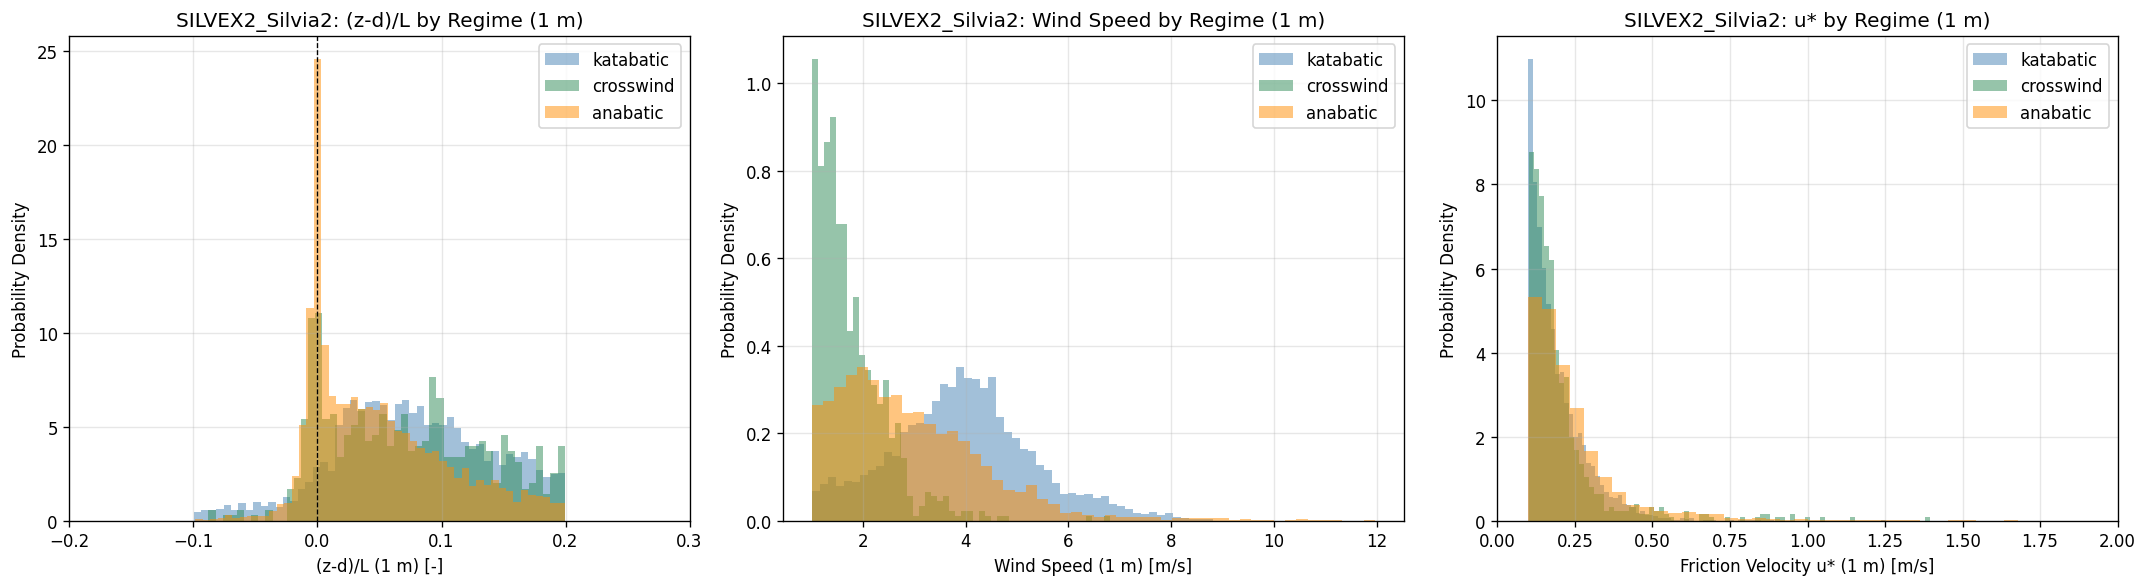

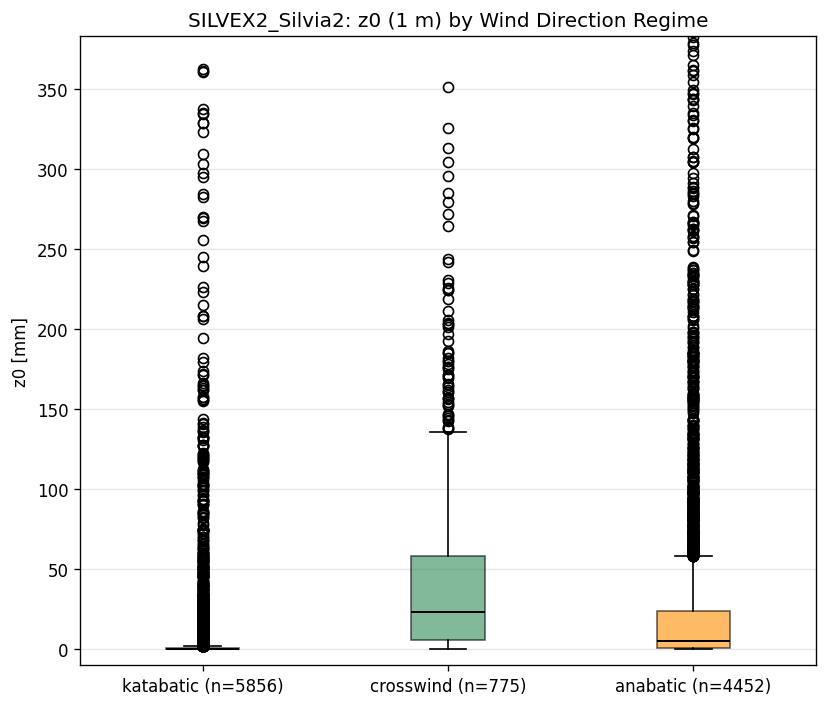

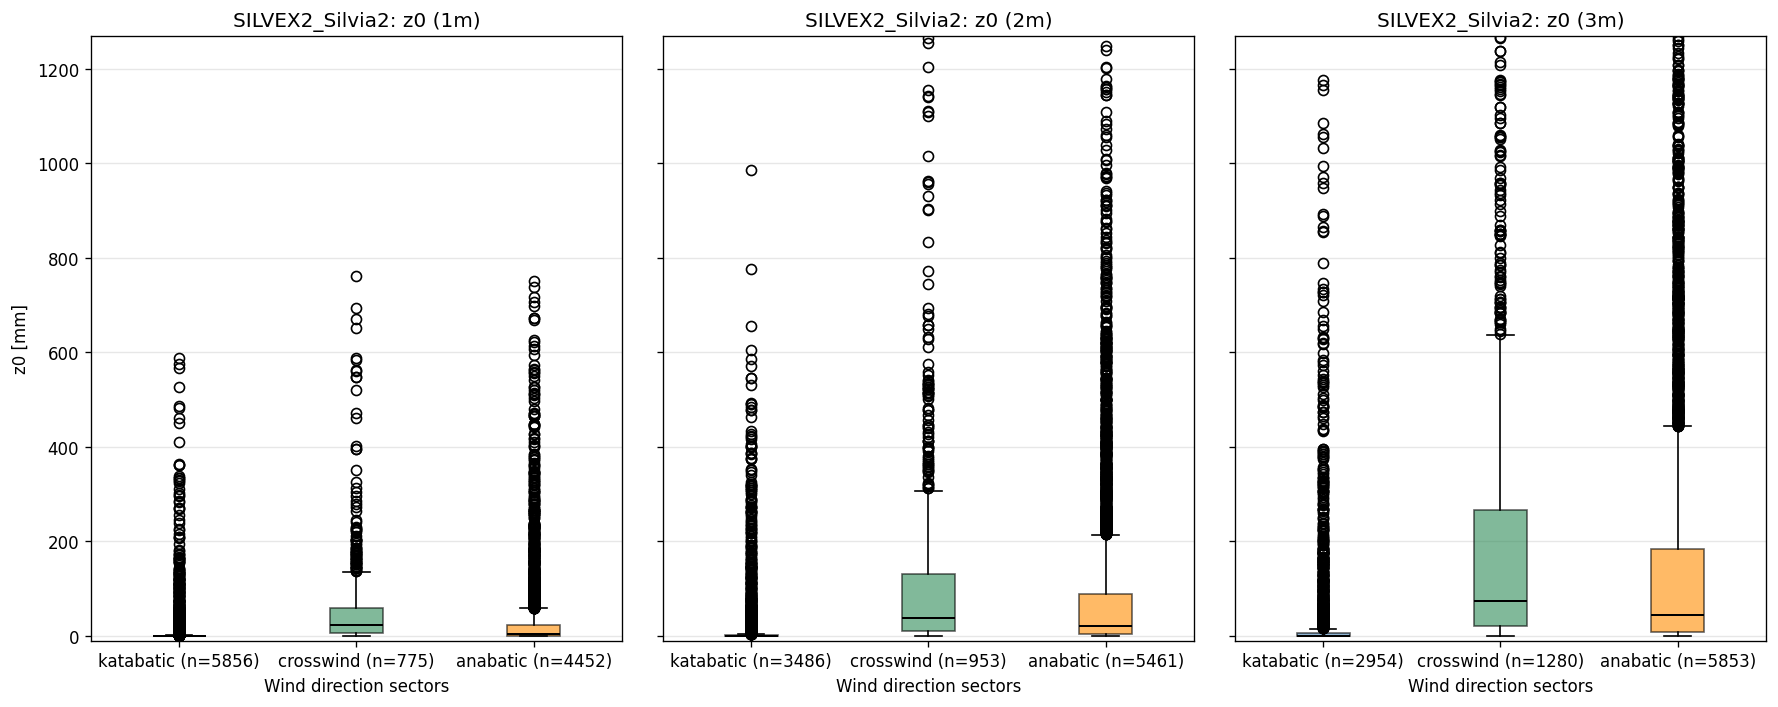

Data successfully filtered!


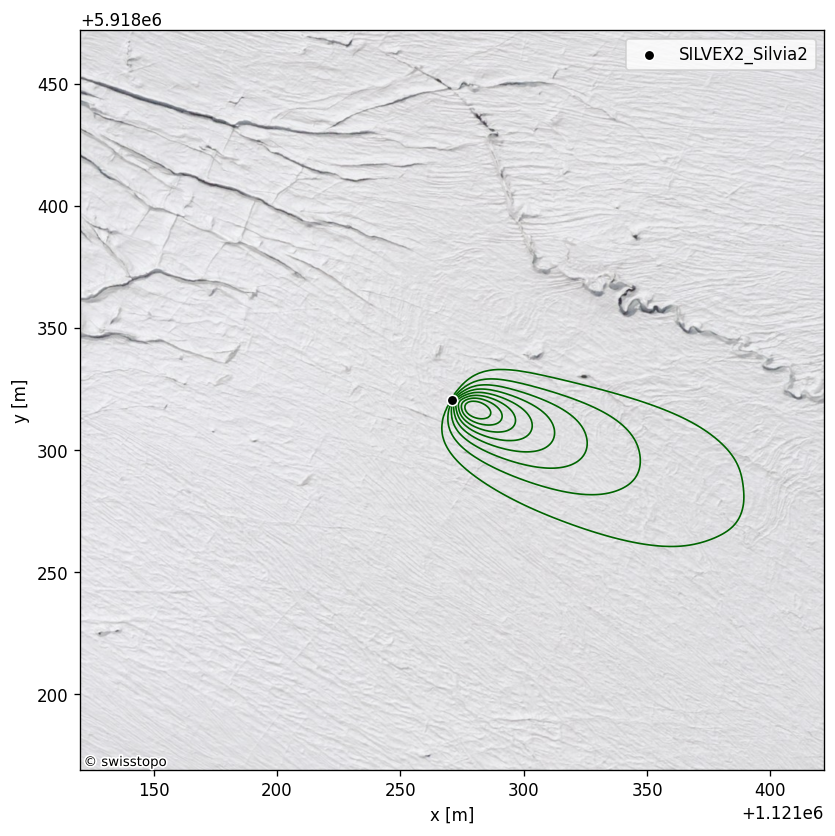

<Figure size 768x576 with 0 Axes>

Data successfully filtered!


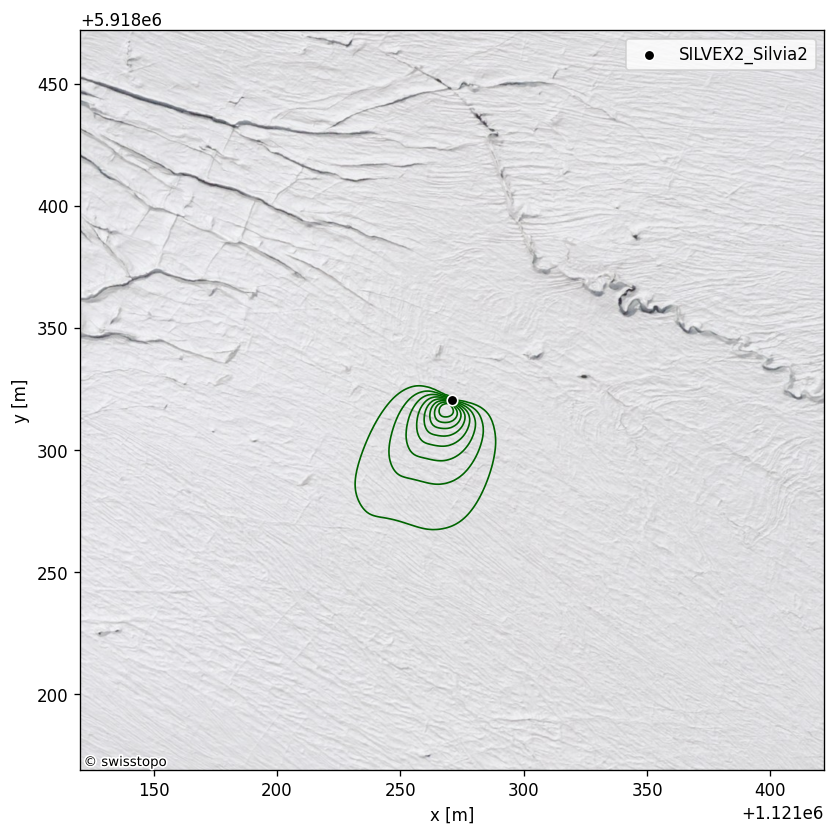

<Figure size 768x576 with 0 Axes>

Data successfully filtered!


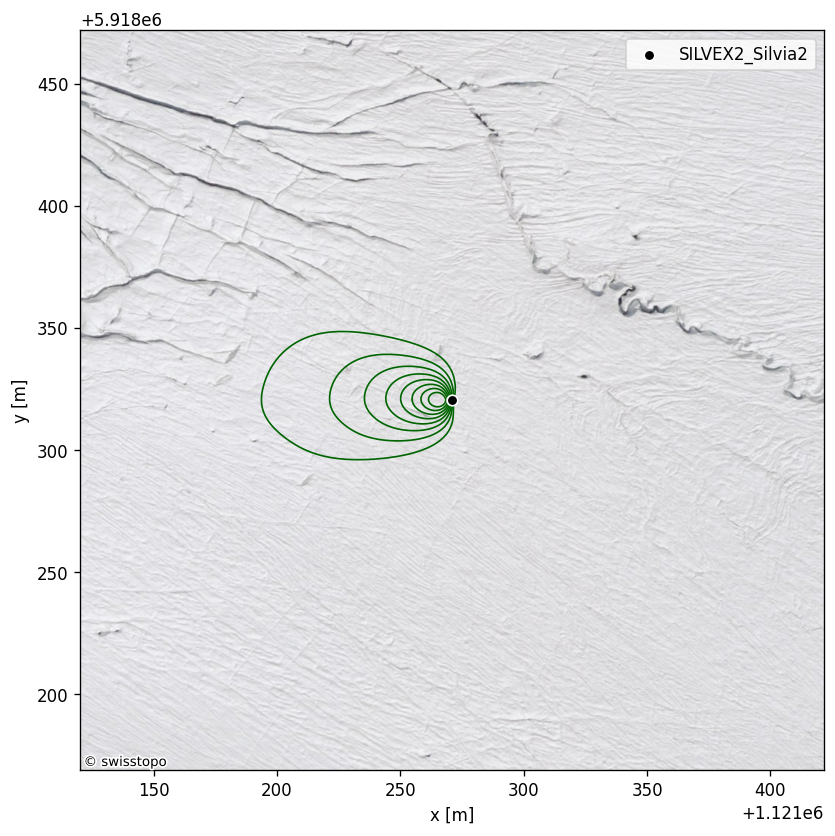

<Figure size 768x576 with 0 Axes>

,station,regime,n_samples
0,SILVEX1_Silvia1,crosswind,125
1,SILVEX1_Silvia1,anabatic,261
2,SILVEX1_Silvia2,crosswind,906
3,SILVEX1_Silvia2,anabatic,276
4,SILVEX2_Silvia1,crosswind,722
5,SILVEX2_Silvia1,anabatic,4056
6,SILVEX2_Silvia2,katabatic,5856
7,SILVEX2_Silvia2,crosswind,775
8,SILVEX2_Silvia2,anabatic,4452



Saved figures under: \\wsl.ch\memo\home_all\asemannp\Code\ec-processing\figures\roughness_generalized


In [4]:
summary_rows = []

for station_name, cfg in STATIONS.items():
    print('\n' + '=' * 90)
    print(f'Processing {station_name}')
    print('=' * 90)

    outdir = FIG_ROOT / station_name
    outdir.mkdir(parents=True, exist_ok=True)

    df_plot, levels = preprocess_station(cfg['file_path'], cfg)

    print(f'[{station_name}] Rows after preprocessing: {len(df_plot)}')
    print(f'[{station_name}] Levels detected: {levels}')

    # Requested figures
    plot_cell12_histograms(df_plot, cfg['wind_regimes'], station_name, outdir)
    plot_cell17_box_1m(df_plot, cfg['wind_regimes'], station_name, outdir)
    plot_cell18_box_all_heights(df_plot, levels, cfg['wind_regimes'], station_name, outdir)

    ffc_rows = plot_cell21_ffc_per_regime(df_plot, station_name, cfg, outdir)
    summary_rows.extend(ffc_rows)

summary_df = pd.DataFrame(summary_rows)
if summary_df.empty:
    print('No FFC regimes were produced. Check coordinates, columns, and filters.')
else:
    display(summary_df)

print(f'\nSaved figures under: {FIG_ROOT.resolve()}')

In [5]:
# Diagnostics: filter waterfall for all stations in one run
# -----------------------------------------------------------------------------
# This cell helps identify where records are removed in the pipeline.
# It prints:
#   1) Preprocess waterfall by station x level x regime
#   2) FFC waterfall by station x regime (for FFC_SETTINGS['height'])
#
# IMPORTANT:
# - Global preprocess uses GLOBAL_RESAMPLE_MINUTES (currently None).
# - FFC diagnostics can use FFC_SETTINGS['resample_minutes'] (currently 30).
#   This is ONLY for the FFC path, not a global pre-filter resample.

import io
from contextlib import redirect_stdout


def _true_mask(index: pd.Index) -> pd.Series:
    return pd.Series(True, index=index)


def _subset_or_resample_silent(df, resample_minutes=None, time_window=None):
    # Silence helper prints to avoid confusing global-vs-FFC interpretation.
    with io.StringIO() as buf, redirect_stdout(buf):
        out = subset_or_resample(
            df,
            resample_minutes=resample_minutes,
            time_window=time_window,
        )
    return out


def build_preprocess_waterfall(station_name: str, cfg: dict) -> pd.DataFrame:
    df = pd.read_csv(cfg['file_path'], sep=';', low_memory=False)

    # Match preprocess_station setup
    df_clean = df.iloc[1:].copy()
    df_clean['datetime'] = pd.to_datetime(
        df_clean['date'].astype(str) + ' ' + df_clean['time'].astype(str),
        format='%d.%m.%Y %H:%M',
        errors='coerce',
    )
    df_clean = df_clean.dropna(subset=['datetime'])
    df_clean = df_clean.set_index('datetime').sort_index()

    for col in df_clean.columns:
        if col not in {'date', 'time'}:
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

    levels = detect_levels(df_clean.columns)

    # Global subset/resample like preprocess_station
    df_clean = _subset_or_resample_silent(
        df_clean,
        resample_minutes=GLOBAL_RESAMPLE_MINUTES,
        time_window=GLOBAL_TIME_WINDOW,
    )

    regimes = cfg['wind_regimes']
    jet_dir_range = regimes.get(PREPROCESS['jet_dir_range_name'])

    rows = []

    for lvl in levels:
        wd_col = f'wind_dir_{lvl}'
        ws_col = f'wind_speed_{lvl}'
        us_col = f'u*_{lvl}'
        uw_col = f'cov_uw_{lvl}'
        uT_col = f'cov_uT_{lvl}'
        z0_col = f'z0_{lvl}'
        st_col = f'(z-d)/L_{lvl}'

        if wd_col not in df_clean.columns:
            continue

        wd = pd.to_numeric(df_clean[wd_col], errors='coerce')
        valid_wd = wd.notna()

        # Optional filters as masks (same logic as preprocess_station)
        ws_mask = _true_mask(df_clean.index)
        if PREPROCESS['wind_speed_range'] is not None and ws_col in df_clean.columns:
            ws_lo, ws_hi = PREPROCESS['wind_speed_range']
            ws = pd.to_numeric(df_clean[ws_col], errors='coerce')
            ws_mask = ws.between(ws_lo, ws_hi, inclusive='both')

        ustar_range_mask = _true_mask(df_clean.index)
        if PREPROCESS['ustar_range'] is not None and us_col in df_clean.columns:
            us_lo, us_hi = PREPROCESS['ustar_range']
            us = pd.to_numeric(df_clean[us_col], errors='coerce')
            ustar_range_mask = us.between(us_lo, us_hi, inclusive='both')

        ustar_min_mask = _true_mask(df_clean.index)
        if PREPROCESS['ustar_min'] is not None and us_col in df_clean.columns:
            us = pd.to_numeric(df_clean[us_col], errors='coerce')
            ustar_min_mask = us >= PREPROCESS['ustar_min']

        jet_mask = direction_mask(wd, jet_dir_range)

        uw_mask = _true_mask(df_clean.index)
        if PREPROCESS['uw_jet_filter'] and uw_col in df_clean.columns:
            uw_mask = (~jet_mask) | (pd.to_numeric(df_clean[uw_col], errors='coerce') <= 0)

        uT_mask = _true_mask(df_clean.index)
        if PREPROCESS['uT_jet_filter'] and uT_col in df_clean.columns:
            uT_mask = (~jet_mask) | (pd.to_numeric(df_clean[uT_col], errors='coerce') >= 0)

        stability_mask = _true_mask(df_clean.index)
        if st_col in df_clean.columns:
            st_lo, st_hi = STABILITY_RANGE
            st = pd.to_numeric(df_clean[st_col], errors='coerce')
            stability_mask = st.between(st_lo, st_hi, inclusive='both')

        for regime_name, regime_rng in regimes.items():
            basic_dir_mask = direction_mask(wd, regime_rng)

            m_basic = basic_dir_mask
            m_ws = m_basic & ws_mask
            m_ur = m_ws & ustar_range_mask
            m_um = m_ur & ustar_min_mask
            m_uw = m_um & uw_mask
            m_uT = m_uw & uT_mask

            # What remains available for z0-based plotting after masking
            if z0_col in df_clean.columns:
                z0 = pd.to_numeric(df_clean[z0_col], errors='coerce')
                n_z0_after_mask = int((m_uT & z0.notna()).sum())
            else:
                n_z0_after_mask = np.nan

            rows.append({
                'station': station_name,
                'level': lvl,
                'regime': regime_name,
                'n_total_rows': int(len(df_clean)),
                'n_valid_wind_dir': int(valid_wd.sum()),
                'n_after_basic_direction': int(m_basic.sum()),
                'n_after_wind_speed': int(m_ws.sum()),
                'n_after_ustar_range': int(m_ur.sum()),
                'n_after_ustar_min': int(m_um.sum()),
                'n_after_uw_jet_filter': int(m_uw.sum()),
                'n_after_uT_jet_filter': int(m_uT.sum()),
                'n_stability_in_range': int((m_uT & stability_mask).sum()),
                'n_z0_non_null_after_mask': n_z0_after_mask,
            })

    return pd.DataFrame(rows)


def build_ffc_waterfall(station_name: str, cfg: dict) -> pd.DataFrame:
    height = FFC_SETTINGS['height']

    needed_cols = [
        f'wind_speed_{height}',
        f'L_{height}',
        f'u*_{height}',
        f'var_v_{height}',
        f'wind_dir_{height}',
    ]

    # Reuse station preprocessing output for FFC path consistency
    df_clean, _ = preprocess_station(cfg['file_path'], cfg)
    n_after_preprocess = int(len(df_clean))

    if not all(c in df_clean.columns for c in needed_cols):
        return pd.DataFrame([
            {
                'station': station_name,
                'height': height,
                'regime': 'all',
                'n_after_preprocess': n_after_preprocess,
                'n_after_ffc_subset_resample': np.nan,
                'n_after_filter_ffp': np.nan,
                'n_after_dropna_needed_cols': np.nan,
                'n_after_sigmav': np.nan,
                'note': f'missing columns for {height}',
            }
        ])

    # This is the ONLY place where FFC-specific resampling/time-window is applied.
    df_ffp = _subset_or_resample_silent(
        df_clean.copy(),
        resample_minutes=FFC_SETTINGS['resample_minutes'],
        time_window=FFC_SETTINGS['time_window'],
    )
    n_after_ffc_subset_resample = int(len(df_ffp))

    if df_ffp.empty:
        return pd.DataFrame([
            {
                'station': station_name,
                'height': height,
                'regime': 'all',
                'n_after_preprocess': n_after_preprocess,
                'n_after_ffc_subset_resample': n_after_ffc_subset_resample,
                'n_after_filter_ffp': 0,
                'n_after_dropna_needed_cols': 0,
                'n_after_sigmav': 0,
                'note': 'empty after FFC subset/resample',
            }
        ])

    regimes = cfg['wind_regimes']
    jet_rng = regimes.get(FFC_SETTINGS['jet_filter_regime_name'])

    rows = []
    for regime_name, regime_rng in regimes.items():
        filtered0 = filter_ffp(
            df_ffp,
            height=height,
            wind_dir_range=regime_rng,
            jet_filter_range=jet_rng,
            uw_jet_filter=FFC_SETTINGS['uw_jet_filter'],
            uT_jet_filter=FFC_SETTINGS['uT_jet_filter'],
            wind_speed_range=FFC_SETTINGS['wind_speed_range'],
        )

        filtered1 = filtered0.dropna(subset=needed_cols).copy()
        filtered1['sigmav'] = np.sqrt(filtered1[f'var_v_{height}'])
        filtered2 = filtered1.dropna(subset=['sigmav'])

        rows.append({
            'station': station_name,
            'height': height,
            'regime': regime_name,
            'n_after_preprocess': n_after_preprocess,
            'n_after_ffc_subset_resample': n_after_ffc_subset_resample,
            'n_after_filter_ffp': int(len(filtered0)),
            'n_after_dropna_needed_cols': int(len(filtered1)),
            'n_after_sigmav': int(len(filtered2)),
            'note': '',
        })

    return pd.DataFrame(rows)


# Run diagnostics for all stations
pre_rows = []
ffc_rows = []
for st, cfg in STATIONS.items():
    pre_rows.append(build_preprocess_waterfall(st, cfg))
    ffc_rows.append(build_ffc_waterfall(st, cfg))

pre_diag = pd.concat(pre_rows, ignore_index=True) if pre_rows else pd.DataFrame()
ffc_diag = pd.concat(ffc_rows, ignore_index=True) if ffc_rows else pd.DataFrame()

if not pre_diag.empty:
    pre_diag = pre_diag.sort_values(['station', 'level', 'regime']).reset_index(drop=True)
if not ffc_diag.empty:
    ffc_diag = ffc_diag.sort_values(['station', 'regime']).reset_index(drop=True)

print('\n' + '=' * 100)
print('SETTINGS CHECK')
print('=' * 100)
print(f'GLOBAL_RESAMPLE_MINUTES = {GLOBAL_RESAMPLE_MINUTES} (global preprocess)')
print(f"FFC_SETTINGS[\'resample_minutes\'] = {FFC_SETTINGS['resample_minutes']} (FFC path only)")

print('\n' + '=' * 100)
print('PREPROCESS WATERFALL (station x level x regime)')
print('=' * 100)
display(pre_diag)

print('\n' + '=' * 100)
print(f"FFC WATERFALL (station x regime, height={FFC_SETTINGS['height']})")
print('=' * 100)
display(ffc_diag)

# Optional quick summary for katabatic only
if not pre_diag.empty and 'katabatic' in set(pre_diag['regime']):
    kat = pre_diag[pre_diag['regime'] == 'katabatic'].copy()
    cols = [
        'station', 'level',
        'n_after_basic_direction',
        'n_after_uw_jet_filter',
        'n_z0_non_null_after_mask',
    ]
    print('\n' + '=' * 100)
    print('KATABATIC QUICK CHECK')
    print('=' * 100)
    display(kat[cols].sort_values(['station', 'level']).reset_index(drop=True))

Data successfully filtered!
Data successfully filtered!
Data successfully filtered!
Data successfully filtered!
Data successfully filtered!
Data successfully filtered!
Data successfully filtered!
Data successfully filtered!
Data successfully filtered!
Data successfully filtered!
Data successfully filtered!
Data successfully filtered!
Data successfully filtered!
Data successfully filtered!
Data successfully filtered!

SETTINGS CHECK
GLOBAL_RESAMPLE_MINUTES = None (global preprocess)
FFC_SETTINGS['resample_minutes'] = None (FFC path only)

PREPROCESS WATERFALL (station x level x regime)


,station,level,regime,n_total_rows,n_valid_wind_dir,n_after_basic_direction,n_after_wind_speed,n_after_ustar_range,n_after_ustar_min,n_after_uw_jet_filter,n_after_uT_jet_filter,n_stability_in_range,n_z0_non_null_after_mask
0,SILVEX1_Silvia1,1m,anabatic,22867,22486,332,280,280,261,261,261,221,261
1,SILVEX1_Silvia1,1m,crosswind,22867,22486,241,143,143,125,125,125,92,125
2,SILVEX1_Silvia1,1m,katabatic,22867,22486,19038,18861,18861,11115,0,0,0,0
3,SILVEX1_Silvia1,2m,anabatic,22867,21833,304,255,255,238,238,238,150,238
4,SILVEX1_Silvia1,2m,crosswind,22867,21833,242,151,151,133,133,133,93,133
5,SILVEX1_Silvia1,2m,katabatic,22867,21833,18221,17991,17991,12964,0,0,0,0
6,SILVEX1_Silvia2,1m,anabatic,24337,24313,353,286,286,276,276,276,265,276
7,SILVEX1_Silvia2,1m,crosswind,24337,24313,1476,1184,1184,906,906,906,800,906
8,SILVEX1_Silvia2,1m,katabatic,24337,24313,20680,20271,20271,12212,0,0,0,0
9,SILVEX1_Silvia2,2m,anabatic,24337,24320,386,310,310,287,287,287,227,287



FFC WATERFALL (station x regime, height=1m)


,station,height,regime,n_after_preprocess,n_after_ffc_subset_resample,n_after_filter_ffp,n_after_dropna_needed_cols,n_after_sigmav,note
0,SILVEX1_Silvia1,1m,anabatic,22867,22867,261,261,261,
1,SILVEX1_Silvia1,1m,crosswind,22867,22867,125,125,125,
2,SILVEX1_Silvia1,1m,katabatic,22867,22867,0,0,0,
3,SILVEX1_Silvia2,1m,anabatic,24337,24337,276,276,276,
4,SILVEX1_Silvia2,1m,crosswind,24337,24337,906,906,906,
5,SILVEX1_Silvia2,1m,katabatic,24337,24337,0,0,0,
6,SILVEX1_Silvia3,1m,anabatic,24504,24504,0,0,0,
7,SILVEX1_Silvia3,1m,crosswind,24504,24504,0,0,0,
8,SILVEX1_Silvia3,1m,katabatic,24504,24504,0,0,0,
9,SILVEX2_Silvia1,1m,anabatic,43281,43281,4056,4056,4056,



KATABATIC QUICK CHECK


,station,level,n_after_basic_direction,n_after_uw_jet_filter,n_z0_non_null_after_mask
0,SILVEX1_Silvia1,1m,19038,0,0
1,SILVEX1_Silvia1,2m,18221,0,0
2,SILVEX1_Silvia2,1m,20680,0,0
3,SILVEX1_Silvia2,2m,19934,0,0
4,SILVEX1_Silvia3,1m,0,0,0
5,SILVEX1_Silvia3,2m,20739,0,0
6,SILVEX2_Silvia1,1m,17945,0,0
7,SILVEX2_Silvia1,2m,16791,0,0
8,SILVEX2_Silvia1,3m,13313,0,0
9,SILVEX2_Silvia2,1m,18713,5856,5856
